In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DIR = Path.cwd().parent.parent / "data" / "processed"
df     = pd.read_csv(PROCESSED_DIR / "starters.csv", parse_dates=["date"])
active = df[~df["scratched"]].copy()

# Stämmer oddsen en häst har med utfallet?

Vi utgår från `active` – samma dataset som tvättades i `01_validate_data` – och filtrerar bort rader där odds saknas. Därefter delar vi in oddsen i åtta intervall (1–3, 3–5, … 50–200) och beräknar faktisk vinstfrekvens per grupp. Varje grupp representeras av medianodds inom intervallet och jämförs mot den implicita sannolikheten 1/odds. Resultatet plottas i ett bubbeldiagram där punktstorleken speglar antalet starter i gruppen.

## Observation: 

Detta är det jag misstänkte, att hästar med lågt odds vinner mer. Detta stämmer mot verkligheten då det är dem lågoddsade hästarna man vill träffa. 


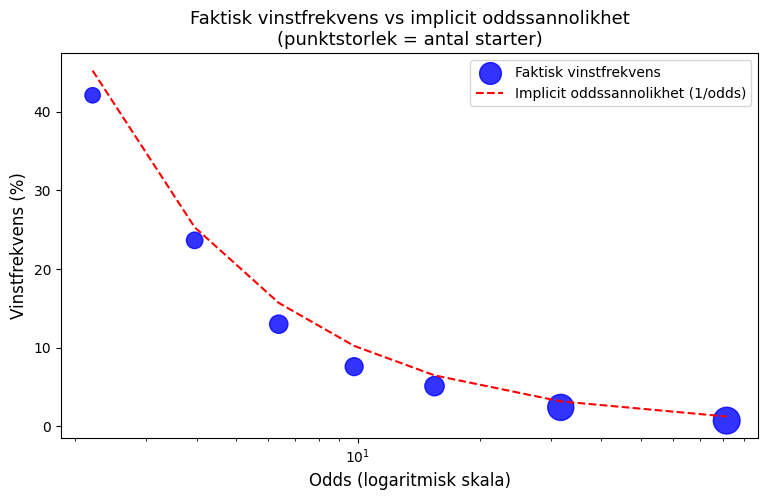

In [57]:
odds_bins = [1, 3, 5, 8, 12, 20, 50, 200]
odds_data = active.dropna(subset=['odds']).copy()
odds_data['odds_grupp'] = pd.cut(odds_data['odds'], bins=odds_bins)

odds_agg = (
    odds_data.groupby('odds_grupp', observed=True)
    .agg(vinstfrekvens=('won', 'mean'), antal=('won', 'count'), mittpunkt=('odds', 'median'))
    .reset_index()
)
odds_agg['mittpunkt'] = odds_agg['mittpunkt'].astype(float)
odds_agg['implicit_sannolikhet'] = 1 / odds_agg['mittpunkt']

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(odds_agg['mittpunkt'], odds_agg['vinstfrekvens'] * 100,
           s=odds_agg['antal'] / 10, color='blue', alpha=0.8, label='Faktisk vinstfrekvens')
ax.plot(odds_agg['mittpunkt'], odds_agg['implicit_sannolikhet'] * 100,
        color='red', linestyle='--', label='Implicit oddssannolikhet (1/odds)')
ax.set_xscale('log')
ax.set_xlabel('Odds (logaritmisk skala)', fontsize=12)
ax.set_ylabel('Vinstfrekvens (%)', fontsize=12)
ax.set_title('Faktisk vinstfrekvens vs implicit oddssannolikhet\n(punktstorlek = antal starter)', fontsize=13)
ax.legend(fontsize=10)

plt.show()

## 2. Spårfördel per bana

Vi utgår från `active` och begränsar analysen till de sex banor med flest starter. För varje bana beräknas vinstfrekvens per spårnummer, där spår med färre än 20 starter exkluderas för att undvika slutsatser på tunn data. Resultatet visas i ett stapeldiagram per bana – totalt sex paneler – så att banspecifika mönster kan jämföras direkt mot varandra.

## Observation: 
Tre mönster är värda att notera:
1. Är vinstfrekvensen konsekvent högre för låga spårnummer på flera banor finns det stöd för en generell innerspårsfördel.
2. Varierar mönstret kraftigt mellan banor tyder det på att fördelen är banspecifik snarare än universell.
3. Banor med jämnare staplar antyder att spårnummer spelar mindre roll – möjligen på grund av banans utformning eller loppens distans.

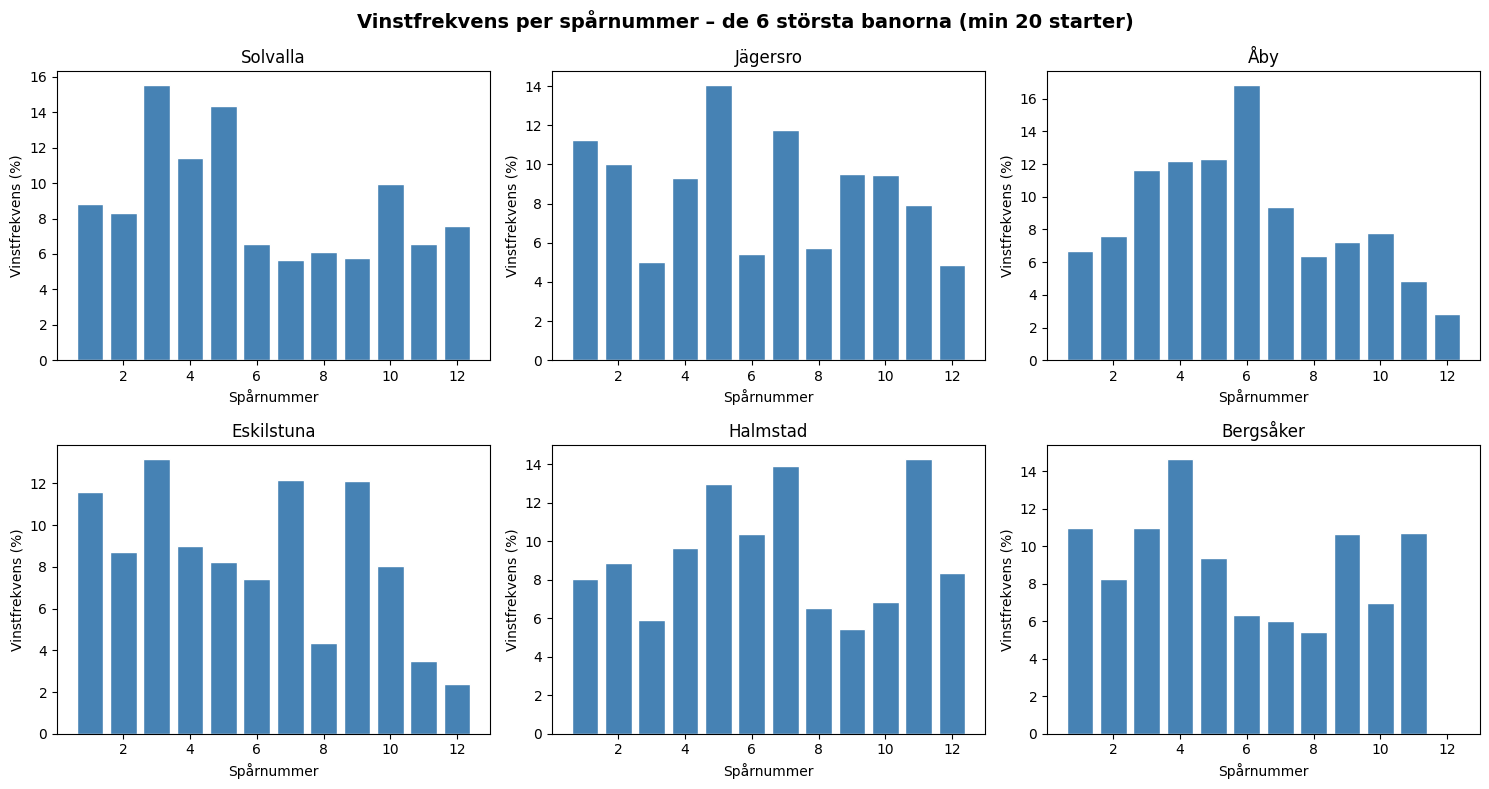

In [61]:
top_tracks = active["track"].value_counts().head(6).index
subset = active[active["track"].isin(top_tracks)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Vinstfrekvens per spårnummer – de 6 största banorna (min 20 starter)", fontsize=14, fontweight="bold")

for ax, track in zip(axes.flatten(), top_tracks):
    track_data = subset[subset["track"] == track]
    pos_stats = (
        track_data.groupby("post_position")
        .agg(win_rate=("won", "mean"), starts=("won", "count"))
        .query("starts >= 20")
    )
    pos_stats["win_rate"] = pos_stats["win_rate"] * 100
    ax.bar(pos_stats.index, pos_stats["win_rate"], color="steelblue", edgecolor="white")
    ax.set_title(track)
    ax.set_xlabel("Spårnummer")
    ax.set_ylabel("Vinstfrekvens (%)")

plt.tight_layout()
plt.show()

## 3. Spårfördel per distans

Vi utgår från `active` och filtrerar på tre av de vanligaste distanserna – 1640 m, 2140 m och 2640 m. För varje distans beräknas vinstfrekvens per spårnummer, där spår med färre än 20 starter exkluderas. Resultatet visas i tre paneler sida vid sida så att distansernas mönster kan jämföras direkt.

Tre mönster är värda att notera:
1. Är innerspårsfördelen tydligare på 1640 m än på längre distanser stärker det hypotesen att ytterlägen hinner kompensera mer ju längre loppet är.
2. Är mönstret likartat över alla tre distanser tyder det på att spårfördelen är strukturell snarare än distansberoende.
3. Försvinner fördelen helt på 2640 m kan det bero på att fältet hunnit jämna ut sig innan första kurvan avgör positionerna.

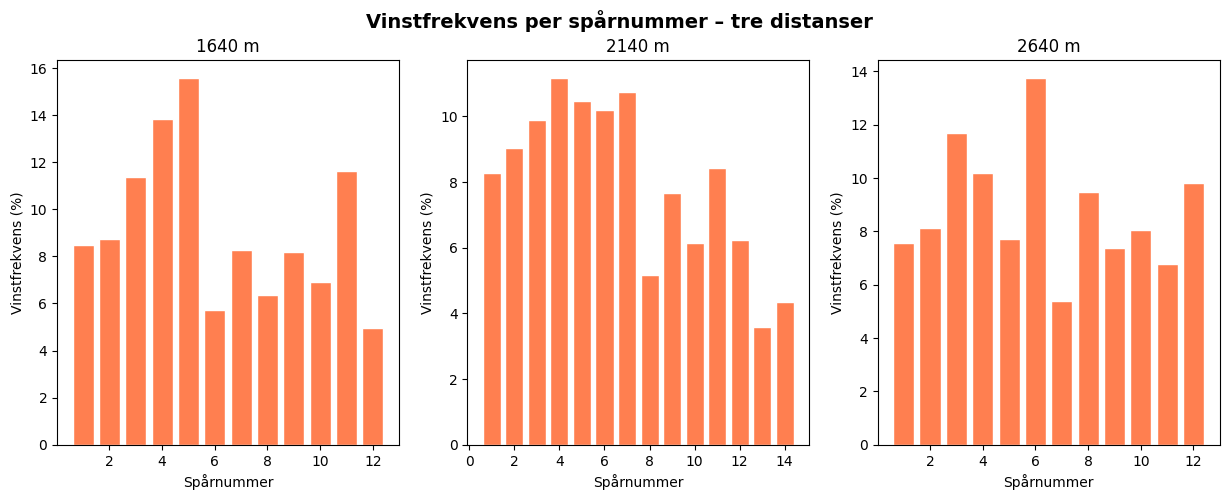

In [62]:
top_distances = [1640, 2140, 2640]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Vinstfrekvens per spårnummer – tre distanser", fontsize=14, fontweight="bold")

for ax, dist in zip(axes, top_distances):
    dist_data = active[active["distance_m"] == dist]
    pos_stats = (
        dist_data.groupby("post_position")
        .agg(win_rate=("won", "mean"), starts=("won", "count"))
        .query("starts >= 20")
    )
    pos_stats["win_rate"] = pos_stats["win_rate"] * 100
    ax.bar(pos_stats.index, pos_stats["win_rate"], color="coral", edgecolor="white")
    ax.set_title(f"{dist} m")
    ax.set_xlabel("Spårnummer")
    ax.set_ylabel("Vinstfrekvens (%)")

plt.show()

Innerspårsfördelen verkar starkare på kortare distanser — något att bekräfta med mer data.

## 4. Spårfördel över tid

**Fråga:** Har innerspårsfördelen hållit sig stabil, eller varierar den över tid?

Om mönstret är konsekvent månad för månad stärker det slutsatsen att det är strukturellt.

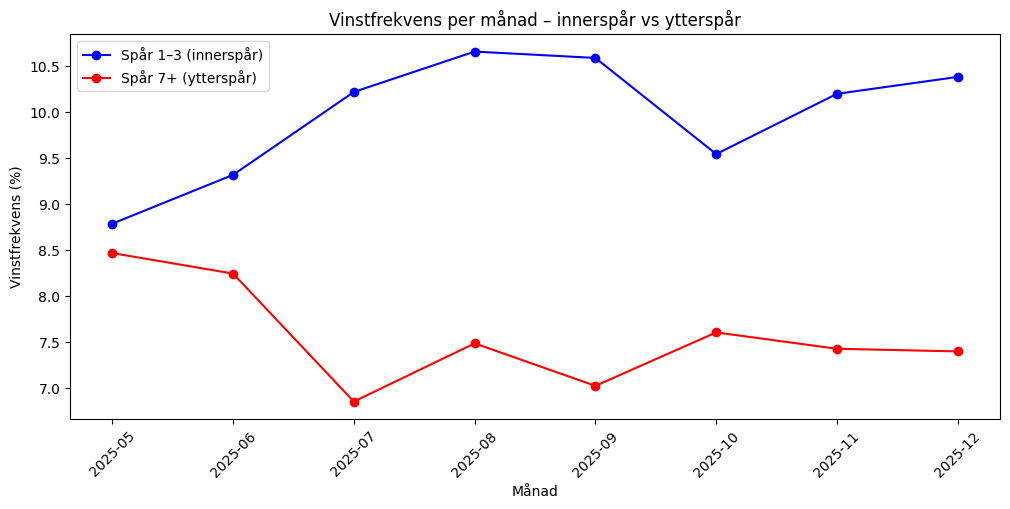

In [65]:
active["month"] = active["date"].dt.to_period("M")
inner = active[active["post_position"] <= 5]
outer = active[active["post_position"] >= 7]

inner_monthly = inner.groupby("month")["won"].mean() * 100
outer_monthly = outer.groupby("month")["won"].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(inner_monthly.index.astype(str), inner_monthly.values,
        marker="o", color="blue", label="Spår 1–3 (innerspår)")
ax.plot(outer_monthly.index.astype(str), outer_monthly.values,
        marker="o", color="red", label="Spår 7+ (ytterspår)")
ax.set_title("Vinstfrekvens per månad – innerspår vs ytterspår")
ax.set_xlabel("Månad")
ax.set_ylabel("Vinstfrekvens (%)")
ax.legend()
ax.tick_params(axis="x", rotation=45)

plt.show()

## 5. Vad analysen visade — och vad den inte kan besvara

**Mönster som blev tydliga genom visualiseringen:**
- Innerspårsfördelen är verklig och konsekvent. Spår 1–3 vinner oftare än spår 7+ på alla undersökta banor och månader.
- Fördelen verkar starkare på kortare distanser (1640m), men underlaget är tunnare där — slutsatsen är preliminär.
- Mönstret håller sig stabilt över tid, vilket tyder på struktur snarare än slump.

**Vad datan inte kan berätta:**
- **Kausalitet:** att innerspår vinner oftare betyder inte att spårnumret *orsakar* vinsten. Tränare och kuskar placerar ofta starka hästar på bra spår — det kan vara hästkvaliteten, inte spåret, som förklarar resultatet.
- **Generaliserbarhet:** datasetet täcker endast V64/V85/V86 under feb–maj 2026. Säsongseffekter och lägre serielopp fångas inte.